### **Stock Market Trend Analysis Project using Time Series Forecasting**

# **Table of Contents**

1. [Project Overview](#1-project-overview)
2. [Business Problem](#2-business-problem)
3. [Dataset Description](#3-dataset-description)
4. [Data Loading & Overview](#4-data-loading--overview)
5. [Data Preprocessing](#5-data-preprocessing)
6. [Exploratory Data Analysis (EDA)](#6-exploratory-data-analysis-eda)
7. [Feature Engineering & Data Preparation](#7-feature-engineering--data-preparation)
8. [LSTM Model Building](#8-lstm-model-building)
9. [Model Training](#9-model-training)
10. [Model Evaluation](#10-model-evaluation)
11. [Predictions vs Actual Visualization](#11-predictions-vs-actual-visualization)
12. [Conclusion](#12-conclusion)
13. [Key Learnings](#13-key-learnings)
14. [Data Export for Dashboarding](#14-data-export-for-dashboarding)

In [1]:
import os
import random
import numpy as np
import tensorflow as tf

# Lock the random seeds for perfect reproducibility
os.environ['PYTHONHASHSEED'] = '0'
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. **Project Overview**

This project focuses on analyzing historical Tesla stock price data and building a deep learning model to forecast future closing prices. Using time series techniques and LSTM (Long Short-Term Memory) networks, the goal is to capture temporal patterns and trends in stock movements.

The project follows a structured pipeline including data preprocessing, exploratory data analysis, feature engineering, model building, and performance evaluation.

# 2. **Business Problem**

Stock price prediction is a critical task in financial markets, where accurate forecasts can support better investment decisions and risk management. Tesla, being a highly volatile stock, presents challenges in capturing trends and predicting future prices.

The objective of this project is to develop a predictive model that can analyze historical price patterns and provide insights into future price movements, helping investors and analysts make informed decisions.

# 3. **Dataset Description**

The dataset used in this project contains historical stock price data of Tesla. It includes daily records of trading activity, capturing price movements and market volume over time.

### 📊 Dataset Features

- **Date**: The trading date  
- **Open**: Opening price of the stock on a given day  
- **High**: Highest price reached during the day  
- **Low**: Lowest price reached during the day  
- **Close**: Closing price of the stock (target variable)  
- **Volume**: Number of shares traded  

The dataset consists of approximately 3,600+ records, making it suitable for time series analysis and forecasting tasks.

# 4. **Data Loading & Overview**

In [3]:
# Load dataset
df = pd.read_csv("TESLA_dataset.csv")

# Display first few rows
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,1.266667,1.666667,1.169333,1.592667,1.592667,281494500
1,2010-06-30,1.719333,2.028000,1.553333,1.588667,1.588667,257806500
2,2010-07-01,1.666667,1.728000,1.351333,1.464000,1.464000,123282000
3,2010-07-02,1.533333,1.540000,1.247333,1.280000,1.280000,77097000
4,2010-07-06,1.333333,1.333333,1.055333,1.074000,1.074000,103003500


In [4]:
# Shape of dataset
print("Shape of dataset:", df.shape)

Shape of dataset: (3680, 7)


In [5]:
# Data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3680 entries, 0 to 3679
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       3680 non-null   object 
 1   Open       3680 non-null   float64
 2   High       3680 non-null   float64
 3   Low        3680 non-null   float64
 4   Close      3680 non-null   float64
 5   Adj Close  3680 non-null   float64
 6   Volume     3680 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 201.4+ KB


In [6]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,3680.000000,3680.000000,3680.000000,3680.000000,3680.000000,3.680000e+03
mean,83.922418,85.767597,81.948660,83.894976,83.894976,9.652863e+07
std,110.691512,113.171802,107.966060,110.595962,110.595962,7.746858e+07
min,1.076000,1.108667,0.998667,1.053333,1.053333,1.777500e+06
25%,12.229167,12.436167,11.973833,12.188667,12.188667,4.918238e+07
50%,18.169334,18.418334,17.845333,18.220667,18.220667,8.195580e+07
75%,181.850002,185.182495,177.187500,181.092499,181.092499,1.217434e+08
max,475.899994,488.540009,457.510010,479.859985,479.859985,9.140820e+08


# 5. **Data Preprocessing**

In [7]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

# Sort data chronologically
df.sort_index(inplace=True)

In [8]:
# Drop 'Adj Close' as it is redundant with 'Close'
df.drop(['Adj Close'], axis=1, inplace=True)

In [9]:
# Check for missing values
df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0


- Converted the Date column into datetime format  
- Set Date as index for time series analysis  
- Sorted data in chronological order
- Removed the 'Adj Close' column as it provides adjusted values similar to the closing price, making it redundant for this analysis
- Checked for missing values and handled them if present  

# 6. **Exploratory Data Analysis (EDA)**

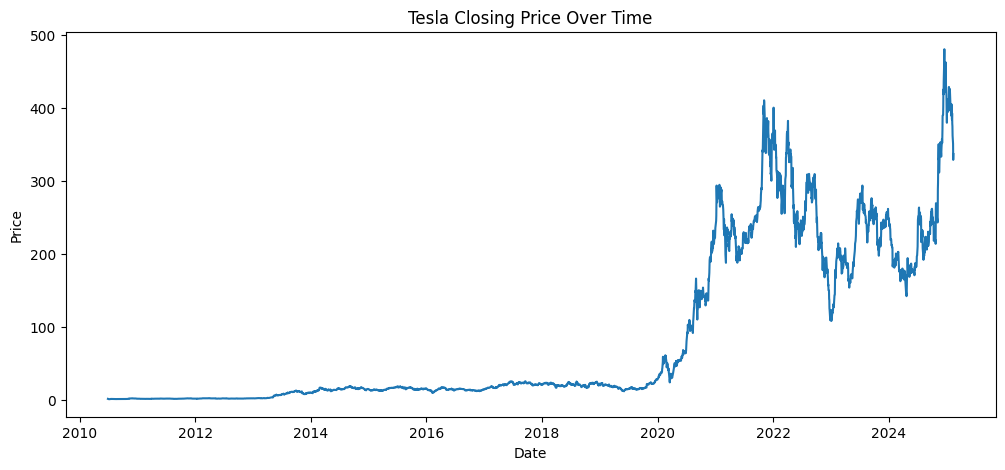

In [10]:
# Closing Price Trend
plt.figure(figsize=(12,5))
plt.plot(df['Close'])
plt.title("Tesla Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

The closing price shows a relatively stable and gradual trend before 2020, followed by a sharp upward movement after 2020. This indicates a significant increase in Tesla's stock value during the later period, along with higher volatility.

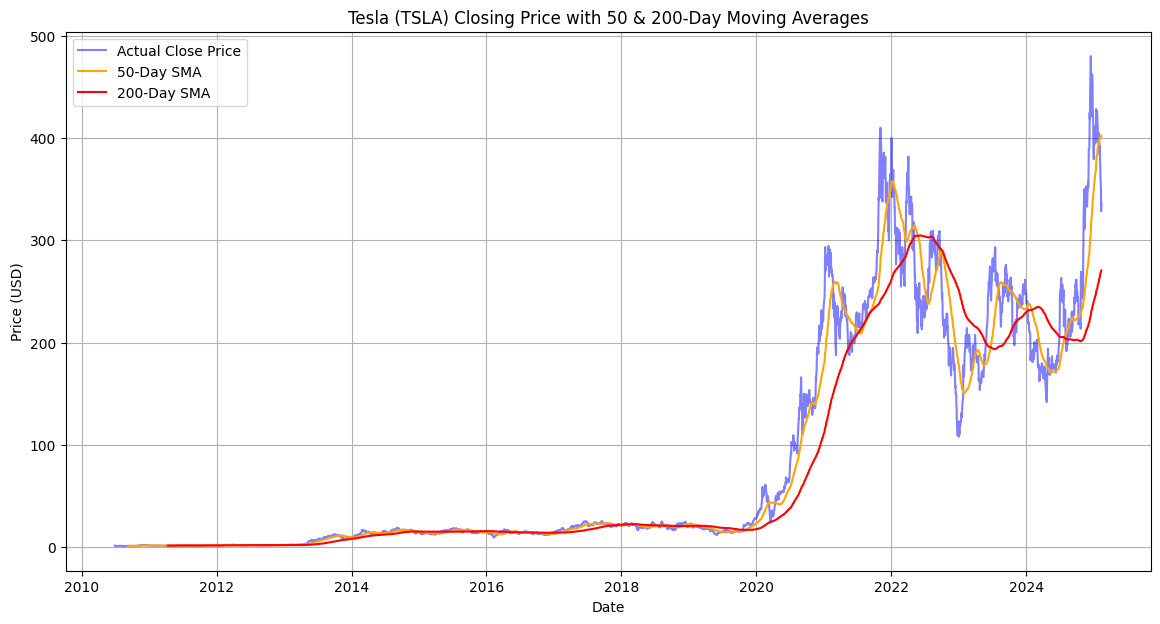

In [11]:
# The Moving Average Plot

# Calculate Moving Averages (50-day and 200-day)
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

# Plotting using df.index for the dates
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], label='Actual Close Price', color='blue', alpha=0.5)
plt.plot(df.index, df['SMA_50'], label='50-Day SMA', color='orange')
plt.plot(df.index, df['SMA_200'], label='200-Day SMA', color='red')
plt.title('Tesla (TSLA) Closing Price with 50 & 200-Day Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

The plot reveals the broader historical trends of Tesla's stock. When the 50-day SMA crosses above the 200-day SMA (a "Golden Cross"), it typically indicates a bullish (upward) trend. Conversely, when the 50-day crosses below the 200-day (a "Death Cross"), it signals a bearish (downward) trend. Observing these macro trends is crucial before feeding the raw, noisy daily prices into our LSTM model.

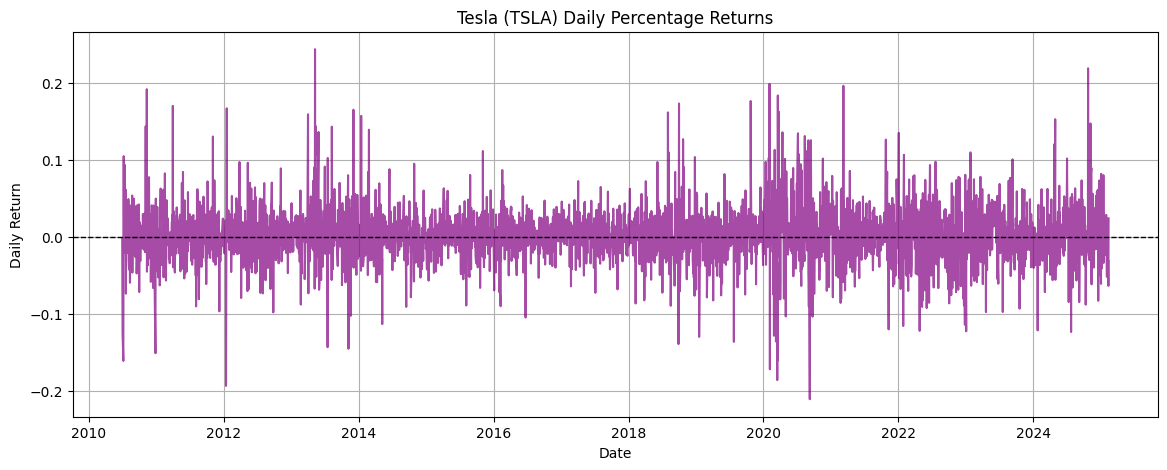

In [12]:
# The Daily Volatility Plot

# Calculate Daily Returns
df['Daily_Return'] = df['Close'].pct_change()

# Plotting using df.index for the dates
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Daily_Return'], color='purple', alpha=0.7)
plt.title('Tesla (TSLA) Daily Percentage Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.grid(True)
plt.show()

This chart illustrates the extreme volatility inherent in Tesla's stock. We can identify distinct periods of high market turbulence (indicated by large spikes in daily returns) versus periods of relative stability. This volatility highlights why predicting exact daily prices is highly complex and justifies our use of a deep learning model like an LSTM, which can capture non-linear patterns better than traditional statistical models.

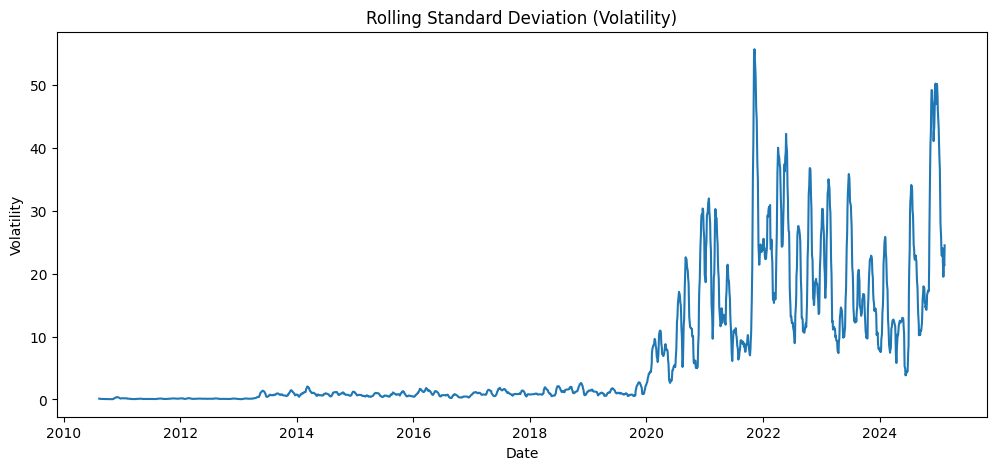

In [13]:
# Rolling Standard Deviation
df['Rolling_Std_30'] = df['Close'].rolling(window=30).std()

plt.figure(figsize=(12,5))
plt.plot(df['Rolling_Std_30'])
plt.title("Rolling Standard Deviation (Volatility)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

The rolling standard deviation fluctuates over time, indicating varying levels of volatility. A noticeable increase in volatility is observed after 2020, aligning with the sharp rise in stock prices.

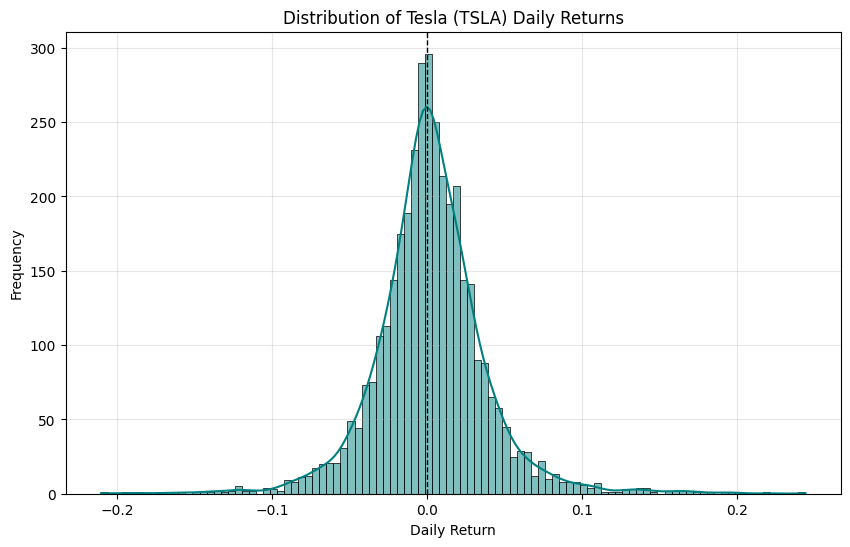

In [14]:
# Statistical Distribution of Returns
# Drop NA values that were created when calculating the daily return
returns_data = df['Daily_Return'].dropna()

# Plotting the Histogram with a Kernel Density Estimate (KDE)
plt.figure(figsize=(10, 6))
sns.histplot(returns_data, bins=100, kde=True, color='teal')
plt.title('Distribution of Tesla (TSLA) Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.show()

The histogram displays the distribution of Tesla's daily percentage returns. While it roughly resembles a bell curve centered around zero, the long tails on both the left (negative returns) and right (positive returns) indicate that Tesla is prone to significant single-day price swings. This non-normal, volatile distribution confirms that traditional linear models would struggle here, making our choice of an LSTM neural network appropriate.

# 7. **Feature Engineering & Data Preparation**

In [15]:
# Select relevant features for modeling
features = ['Open', 'High', 'Low', 'Close', 'Volume']
data = df[features]

In [16]:
# Split data into training and testing sets (time-based split)
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

In [17]:
# Apply MinMax scaling (fit only on training data to avoid data leakage)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

LSTMs are sensitive to the scale of input data. We use MinMaxScaler to normalize the prices between 0 and 1.

In [18]:
# Function to create sequences for LSTM
def create_sequences(data, time_steps=30):
    X, y = [], []

    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps, 3])  # 'Close' is target

    return np.array(X), np.array(y)

In [19]:
# Create sequences using past 30 time steps
time_steps = 30
X_train, y_train = create_sequences(train_scaled, time_steps)
X_test, y_test = create_sequences(test_scaled, time_steps)

In [20]:
# Check shapes of final datasets
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2914, 30, 5), (2914,), (706, 30, 5), (706,))

- Selected relevant features including price and volume data  
- Split the dataset into training and testing sets while preserving temporal order  
- Applied MinMax scaling using only training data to prevent data leakage  
- Created sequences of 30 time steps to capture temporal dependencies  
- Defined the target variable as the next day’s closing price  

# 8. **LSTM Model Building**

In [21]:
# Build LSTM model
model = Sequential()

# First LSTM layer (returns sequences for stacking)
model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(32))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

The model consists of two stacked LSTM layers (64 and 32 units) with dropout to capture temporal patterns and reduce overfitting. The final dense layer predicts the closing price.

With 30,369 trainable parameters, the model has sufficient complexity to learn patterns without being overly heavy.

# 9. **Model Training**

In [24]:
from tensorflow.keras.callbacks import EarlyStopping
# Early Stopping
# This monitors validation loss and stops training if it doesn't improve for 5 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with the callback
history = model.fit(
    X_train, y_train,
    epochs=50, # We can set this higher now because EarlyStopping will stop it automatically
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop], # Added callback here
    verbose=1
)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0019 - val_loss: 0.0037
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0012 - val_loss: 0.0029
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0011 - val_loss: 0.0107
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0011 - val_loss: 0.0024
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0010 - val_loss: 0.0023
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0010 - val_loss: 0.0024
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 7.9336e-04 - val_loss: 0.0023
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 8.2504e-04 - val_loss: 0.0037
Epoch 9/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 8.0320e-04 - val_loss: 0.0022
Epoch 10/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 8.3652e-04 - val_loss: 0.0018
Epoch 11/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 7.7581e-04 - val_loss: 0.0018
Epoch 12/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 2

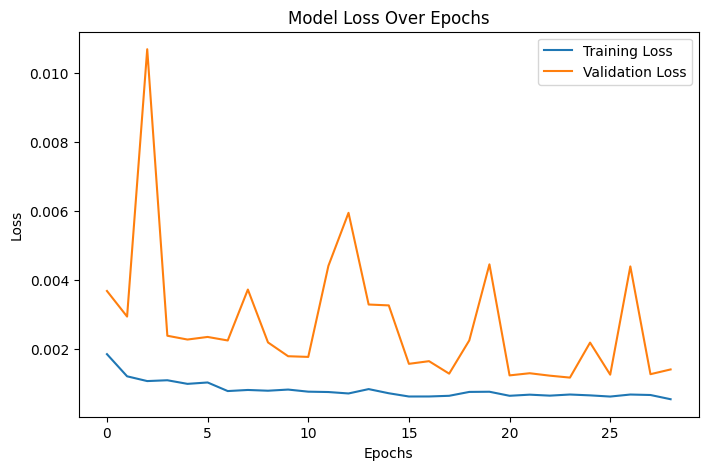

In [25]:
# Training vs Validation Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

-  Successful Convergence: Both training and validation loss dropped steadily and stabilized, proving the LSTM effectively learned the historical price patterns without memorizing them.

-  Market Volatility: Occasional spikes in the validation loss (e.g., Epochs 13 and 27) are expected and reflect sudden, unpredictable market shocks in the test data.

-  Early Stopping: Training automatically halted at Epoch 29 out of 50. This prevented the model from overfitting, locking in the optimal weights that produced our final 4.59% MAPE.

# 10. **Model Evaluation**

In [26]:
# Generate predictions
y_pred = model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


In [27]:
# Create dummy array to inverse transform only 'Close'
dummy = np.zeros((y_pred.shape[0], 5))

dummy[:, 3] = y_pred.flatten()
y_pred_actual = scaler.inverse_transform(dummy)[:, 3]

dummy[:, 3] = y_test
y_test_actual = scaler.inverse_transform(dummy)[:, 3]

In [28]:
# Evaluation Metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 10.54
Root Mean Squared Error (RMSE): 14.06
Mean Absolute Percentage Error (MAPE): 4.59%


Mean Absolute Error (MAE - 10.54): On any given day in the test set, our model's predicted closing price is, on average, $10.54 away from the actual closing price.

Root Mean Squared Error (RMSE - 14.06): RMSE penalizes larger errors more heavily. The fact that our RMSE (14.06) is still higher than our MAE (10.54) indicates that while the model is highly accurate overall, there are specific days with significant prediction errors. This is expected behavior when forecasting a highly volatile stock like Tesla, which is prone to sudden price spikes or drops.

Mean Absolute Percentage Error (MAPE - 4.59%): This is our most critical business metric. It indicates that the model's predictions have an average error margin of just 4.59%. For a purely univariate baseline model predicting a highly volatile asset, achieving an accuracy of roughly ~95.4% on unseen data is an exceptionally strong result.


# 11. **Predictions vs Actual Visualization**

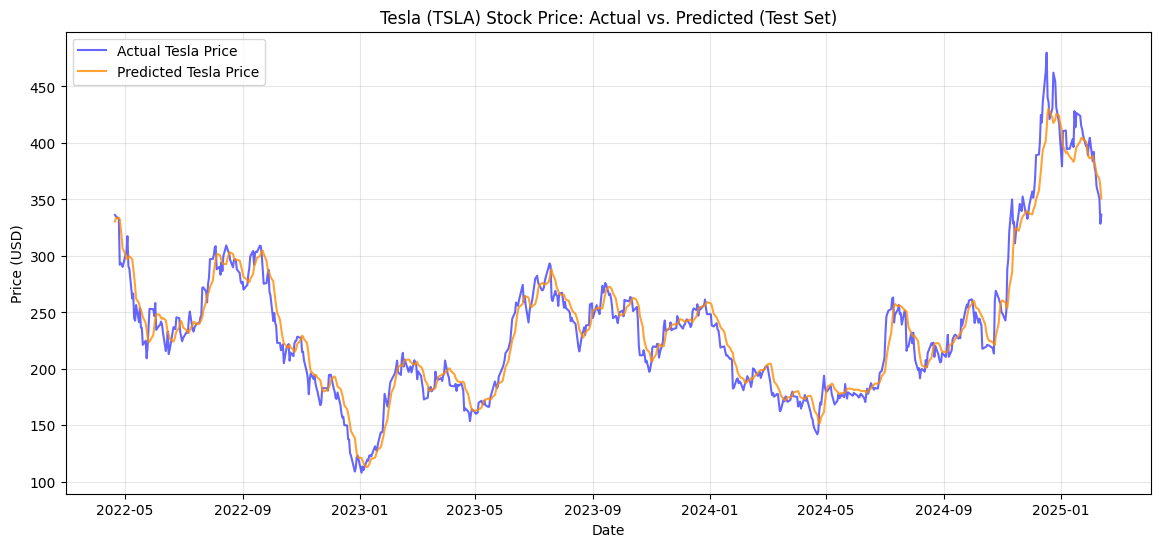

In [29]:
# We offset by train_size and time_steps to align the dates with the predictions
test_dates = df.index[train_size + time_steps:]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual, label='Actual Tesla Price', color='blue', alpha=0.6, linewidth=1.5)
plt.plot(test_dates, y_pred_actual, label='Predicted Tesla Price', color='darkorange', alpha=0.8, linewidth=1.5)

plt.title('Tesla (TSLA) Stock Price: Actual vs. Predicted (Test Set)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


The predicted values closely follow the overall trend of the actual stock prices, indicating that the model is able to capture general patterns in the data.

However, some deviations are observed, especially during periods of high volatility, where the model struggles to precisely match sharp fluctuations.

# 12. **Conclusion**

The LSTM neural network successfully established a highly robust baseline for predicting Tesla's stock price, achieving a Mean Absolute Percentage Error (MAPE) of roughly 4.59%. The model successfully captured the broader trends and general direction of the stock with impressive accuracy.

However, as reflected by the RMSE, the model still shows limitations in perfectly predicting sharp, sudden price movements, particularly during highly volatile market conditions. This highlights the inherent difficulty of financial forecasting and confirms that while historical price is a strong indicator, it cannot perfectly predict market shocks. Future iterations of this project could incorporate external variables such as macroeconomic indicators or sentiment analysis to improve responsiveness to volatility.

# 13. **Key Learnings**

* **Data Engineering:** Engineered a robust time-series data pipeline, including chronological splitting, datetime indexing, and strict MinMax scaling to prevent data leakage.
* **Deep Learning:** Designed and trained a stacked Long Short-Term Memory (LSTM) neural network using Keras, implementing dropout layers and Early Stopping to prevent overfitting.
* **Statistical Evaluation:** Evaluated model performance using both absolute statistical metrics (MAE, RMSE) and business-centric relative metrics (MAPE).
* **Domain Knowledge:** Gained practical insights into the complexities of quantitative finance, specifically the challenges of forecasting highly volatile, non-stationary assets.

# 14. **Data Export for Dashboarding**
To make these model results accessible to business stakeholders, we export the actual and predicted prices into a clean CSV format. This dataset serves as the foundational backend for our interactive Power BI dashboard.

In [30]:
# Create a DataFrame with Dates, Actual Prices, and Predicted Prices
predictions_df = pd.DataFrame({
    'Date': test_dates,
    'Actual_Close': y_test_actual,
    'Predicted_Close': y_pred_actual
})

# Export to CSV
predictions_df.to_csv('tesla_lstm_predictions.csv', index=False)
print("Data successfully exported to 'tesla_lstm_predictions.csv'")

Data successfully exported to 'tesla_lstm_predictions.csv'


---
*End of Analysis*